In [20]:
def ned_to_nes(ned):
    ned = ned / 100.0
    nes = 1 - ned
    nes = nes*100
    return round(nes, 2)

def f1_score(ned, rned):
    ned = ned / 100.0
    rned = rned / 100.0
    if ned + rned == 0:
        return 0.0
    f1 = 2 * (ned * rned) / (ned + rned)
    f1 = f1*100
    return round(f1, 2)

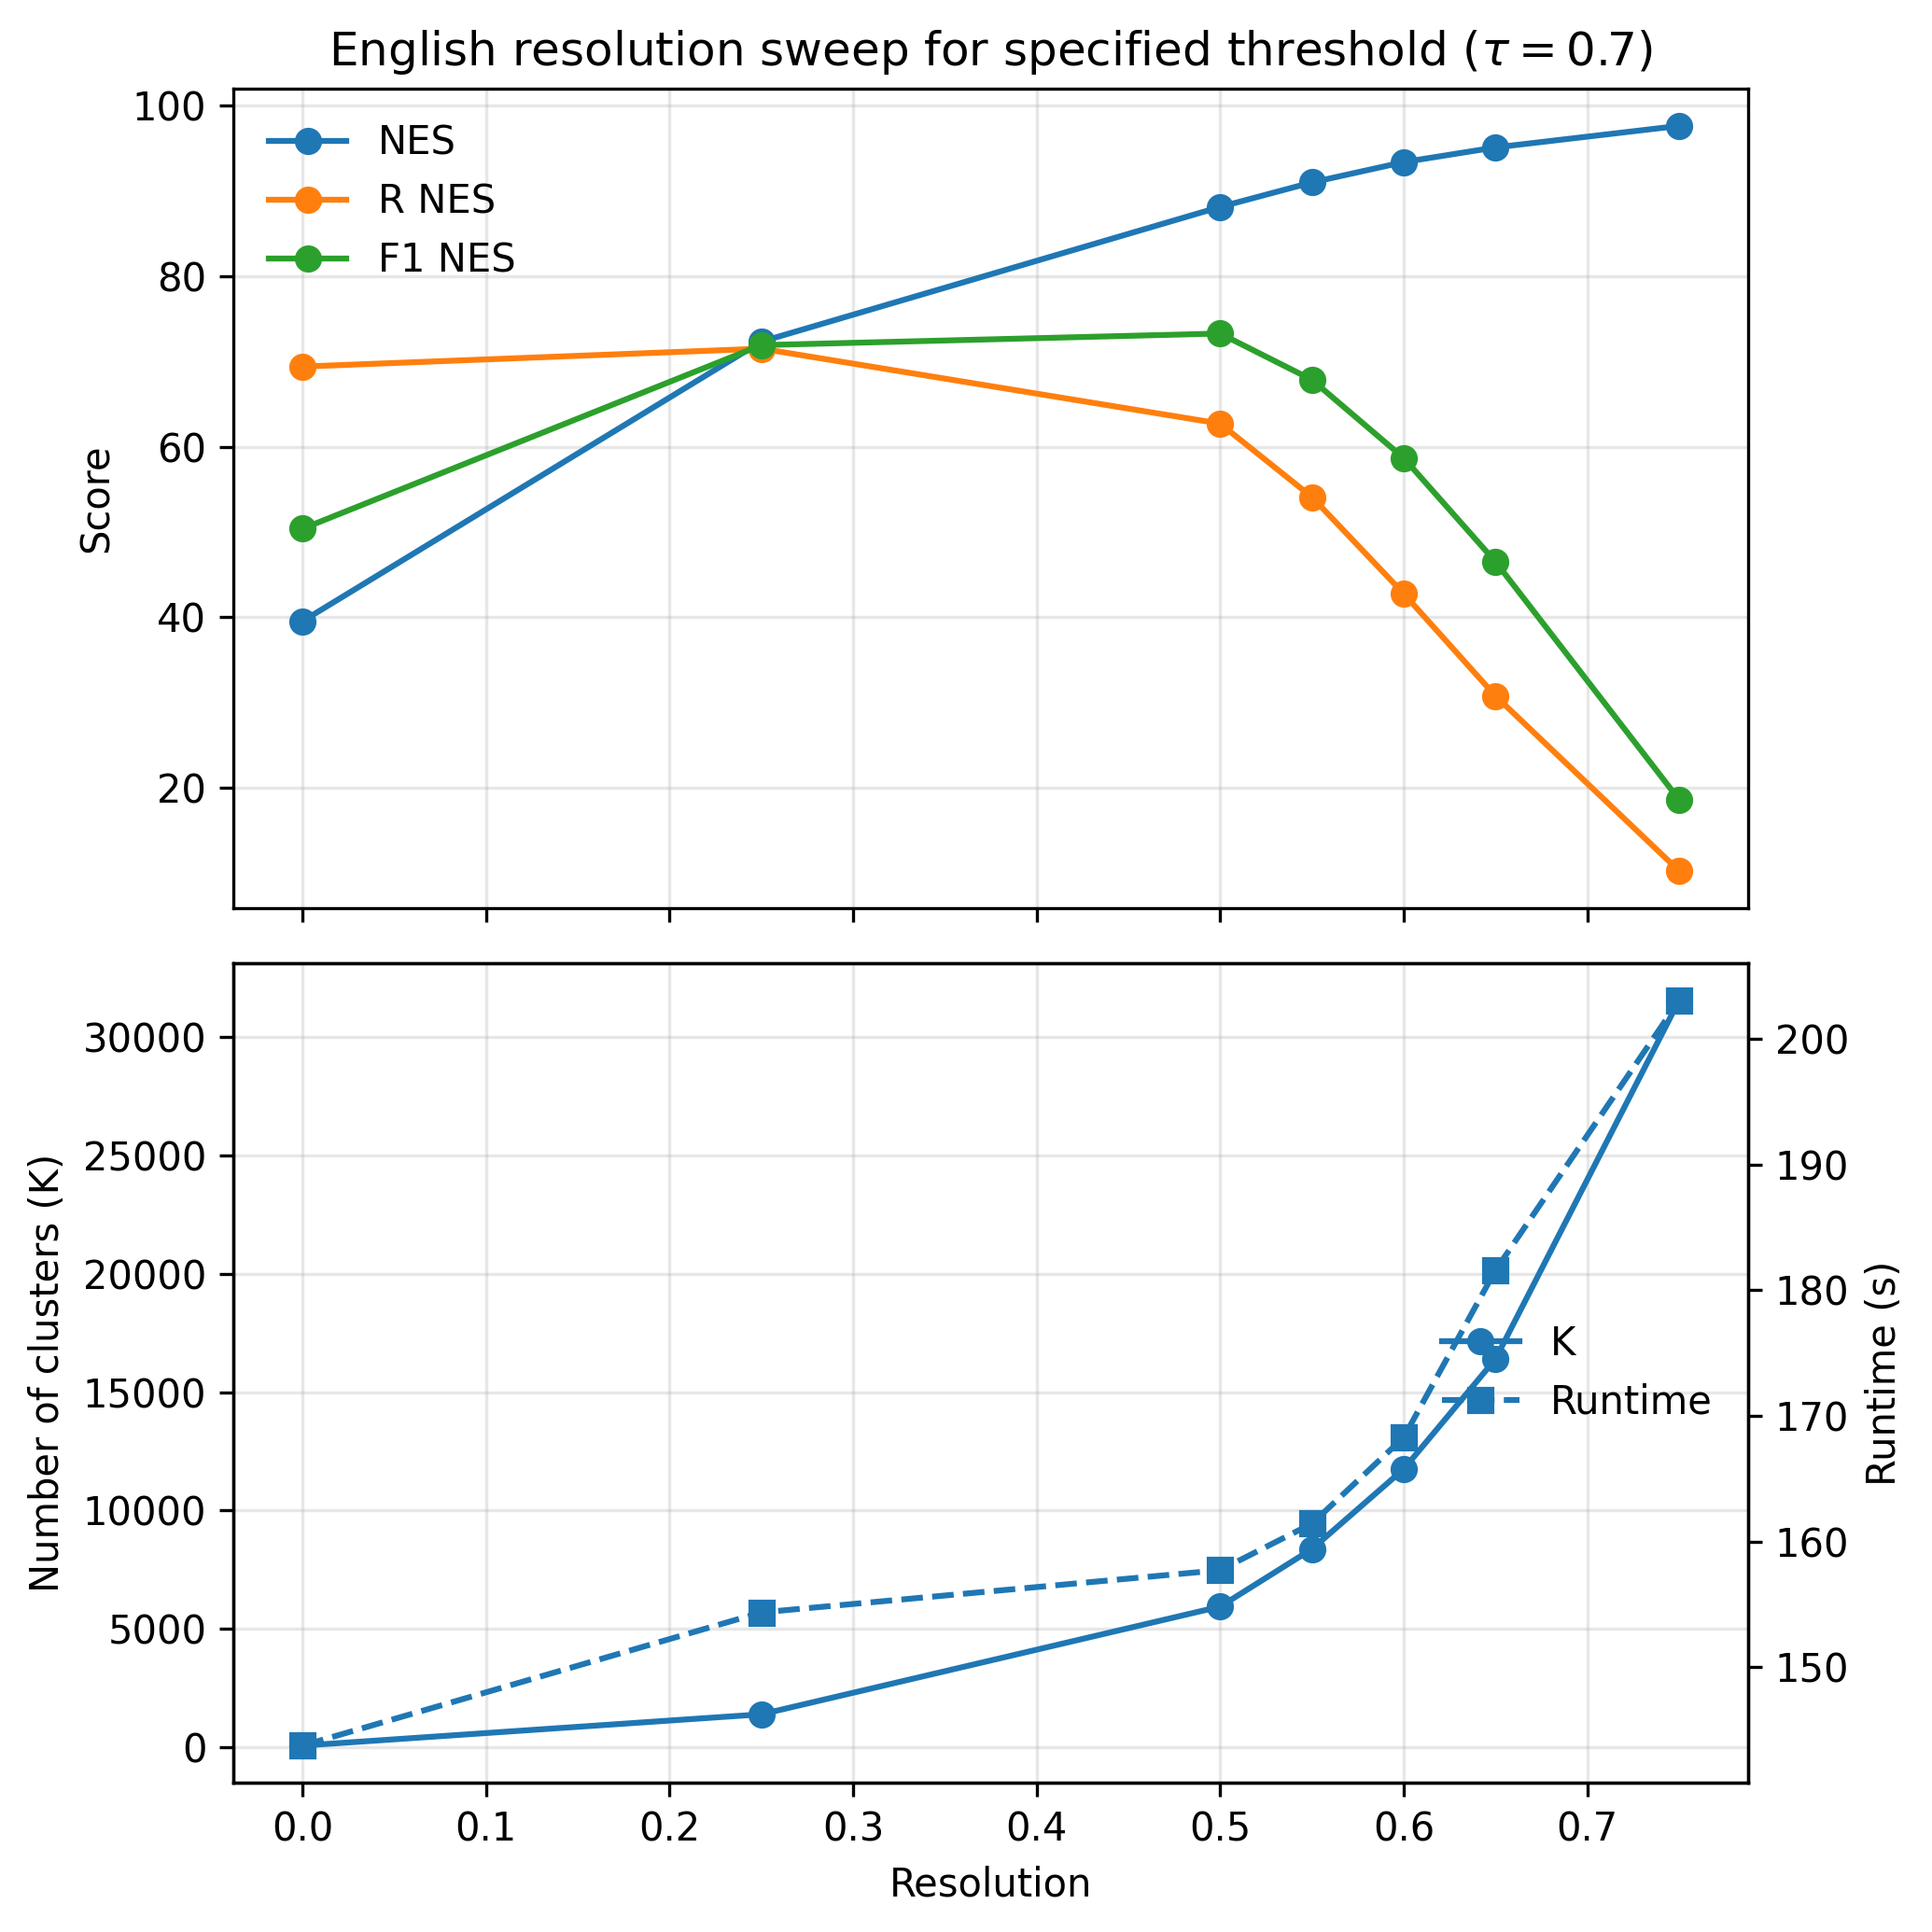

In [3]:
import numpy as np
import matplotlib.pyplot as plt

resolution = np.array([0.0, 0.25, 0.5, 0.55, 0.6, 0.65, 0.75])
K = np.array([59, 1381, 5932, 8364, 11743, 16391, 31537])
nes = np.array([39.56, 72.30, 88.08, 90.95, 93.33, 95.05, 97.57])
rnes = np.array([69.38, 71.48, 62.70, 54.10, 42.79, 30.81, 10.33])
f1_nes = np.array([50.39, 71.89, 73.25, 67.84, 58.68, 46.54, 18.68])
bitrate = np.array([20.15, 29.90, 36.04, 38.20, 40.72, 43.58, 49.57])
runtime = np.array([143.78, 154.37, 157.73, 161.43, 168.28, 181.57, 203.01])


def plot_metrics(nes, rnes, f1_nes, K, runtime, independent_variable, independent_variable_name, title):
    fig, axes = plt.subplots(2, 1, figsize=(7, 7), dpi=300, sharex=True)

    # Top panel
    axes[0].plot(independent_variable, nes, marker='o', label='NES')
    axes[0].plot(independent_variable, rnes, marker='o', label='R NES')
    axes[0].plot(independent_variable, f1_nes, marker='o', label='F1 NES')
    axes[0].set_ylabel('Score')
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(frameon=False)

    # Bottom panel
    ax2 = axes[1]
    ax2.plot(independent_variable, K, marker='o', label='K')
    ax2.set_ylabel('Number of clusters (K)')
    ax2.set_xlabel(f'{independent_variable_name.capitalize()}')
    ax2.grid(True, alpha=0.3)

    ax2b = ax2.twinx()
    ax2b.plot(independent_variable, runtime, marker='s', linestyle='--', label='Runtime')
    ax2b.set_ylabel('Runtime (s)')

    # Combined legend for bottom panel
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='center right')

    plt.tight_layout()
    plt.show()

plot_metrics(nes, rnes, f1_nes, K, runtime, resolution, 'resolution', title='English resolution sweep for specified threshold ($\\tau=0.7$)')

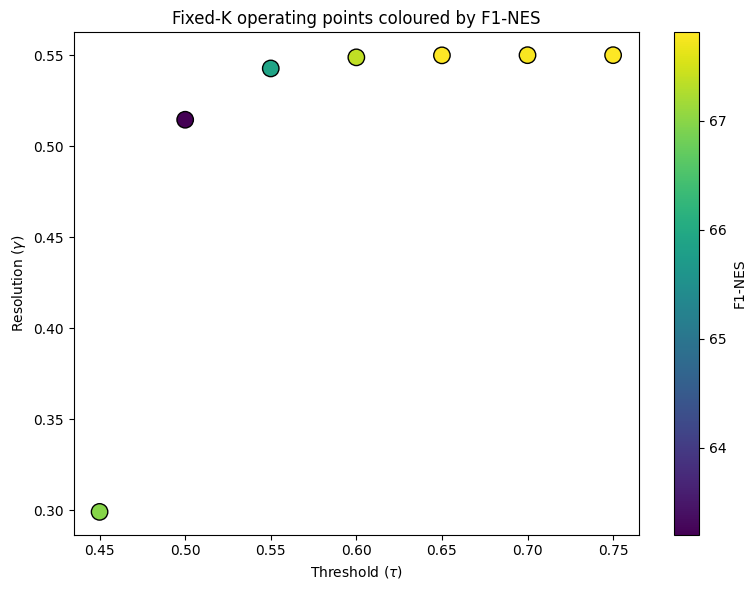

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Your data
threshold = np.array([0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75])
resolution = np.array([0.2990, 0.5146, 0.5428, 0.5489, 0.5500, 0.5501, 0.5501])

# assumes nes and rnes already exist
# and f1_score(n, r) returns F1-NES
f1_nes = np.array([f1_score(n, r) for n, r in zip(nes, rnes)])

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    threshold,
    resolution,
    c=f1_nes,
    s=140,
    cmap="viridis",
    edgecolor="black"
)

cbar = plt.colorbar(sc)
cbar.set_label("F1-NES")

plt.xlabel("Threshold ($\\tau$)")
plt.ylabel("Resolution ($\\gamma$)")
plt.title("Fixed-K operating points coloured by F1-NES")
plt.tight_layout()
plt.show()

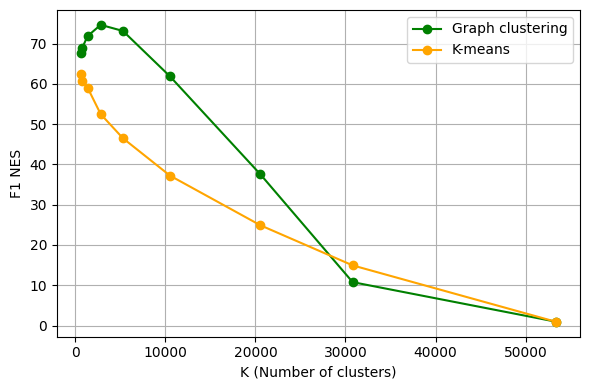

In [4]:
import matplotlib.pyplot as plt

# Graph clustering data
thresholds = [0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
clusters = [610, 755, 1_381, 2_830, 5_302, 10_521, 20_563, 30_794, 53_392]
# nes_graph = [99.92, 98.64, 96.54, 93.73, 89.74, 88.3, 88.08, 88.07]
# r_nes_graph = [0.42, 4.18, 16.18, 33.78, 49.42, 59.96, 62.7, 62.81]
f1_graph = [67.65, 68.83, 71.89, 74.67, 73.15, 61.88, 37.53, 10.78, 0.94]

# K-means (matched K)
f1_kmeans = [62.37, 60.75, 59.05, 52.50, 46.51, 37.23, 24.89, 14.94, 0.91]

# nes_kmeans = [99.93, 98.66, 96.36, 92.00, 87.70, 85.84, 85.55, 85.80]
# r_nes_kmeans = [0.16, 1.34, 3.91, 6.87, 10.09, 11.81, 12.06, 12.07]

plt.figure(figsize=(6,4))

plt.plot(clusters, f1_graph, marker='o', color="green", label='Graph clustering')
# plt.plot(thresholds, r_nes_graph, marker='x', linestyle='--', color="blue", label='R-NES (Graph)', alpha=0.4)
# plt.plot(thresholds, nes_graph, marker='x', linestyle='--', color="blue", label='NES (Graph)', alpha=0.4)
plt.plot(clusters, f1_kmeans, marker='o', color="orange", label='K-means')
# plt.plot(thresholds, r_nes_kmeans, marker='d', linestyle='--', color="red", label='R-NES (K-means)', alpha=0.4)
# plt.plot(thresholds, nes_kmeans, marker='d', linestyle='--', color="red", label='NES (K-means)', alpha=0.4)
 
plt.xlabel('K (Number of clusters)')
plt.ylabel('F1 NES')
# plt.title('F1 vs Threshold (English, Graph Clustering vs K-means)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

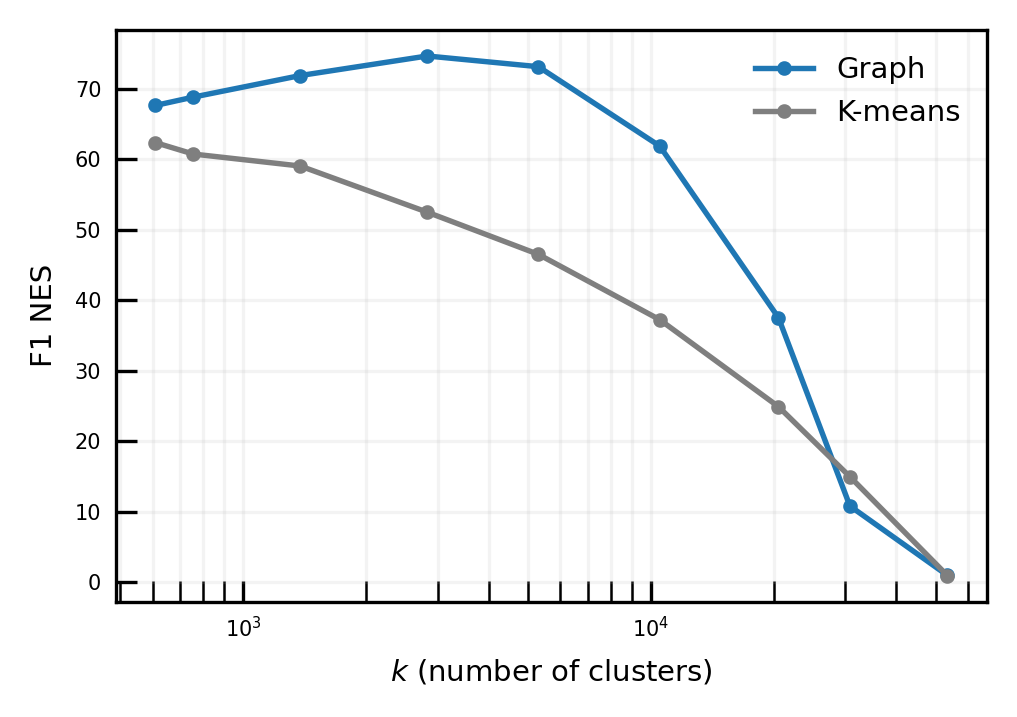

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

thresholds = [0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
clusters = [610, 755, 1_381, 2_830, 5_302, 10_521, 20_563, 30_794, 53_392]
f1_graph = [67.65, 68.83, 71.89, 74.67, 73.15, 61.88, 37.53, 10.78, 0.94]
f1_kmeans = [62.37, 60.75, 59.05, 52.50, 46.51, 37.23, 24.89, 14.94, 0.91]

fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)

ax.plot(
    clusters, f1_graph,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color="tab:blue",
    label="Graph",
)

ax.plot(
    clusters, f1_kmeans,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color="tab:gray",
    label="K-means",
)

ax.set_xscale("log")
ax.set_xlabel(r"$k$ (number of clusters)")
ax.set_ylabel(r"F1 NES")

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

ax.legend(frameon=False, loc="best")

fig.tight_layout()
fig.suptitle("F1 NES vs $k$ (English, Graph Clustering vs K-means)")
fig.savefig("figs/f1_vs_k_log_scale.pdf", bbox_inches="tight")
plt.show()

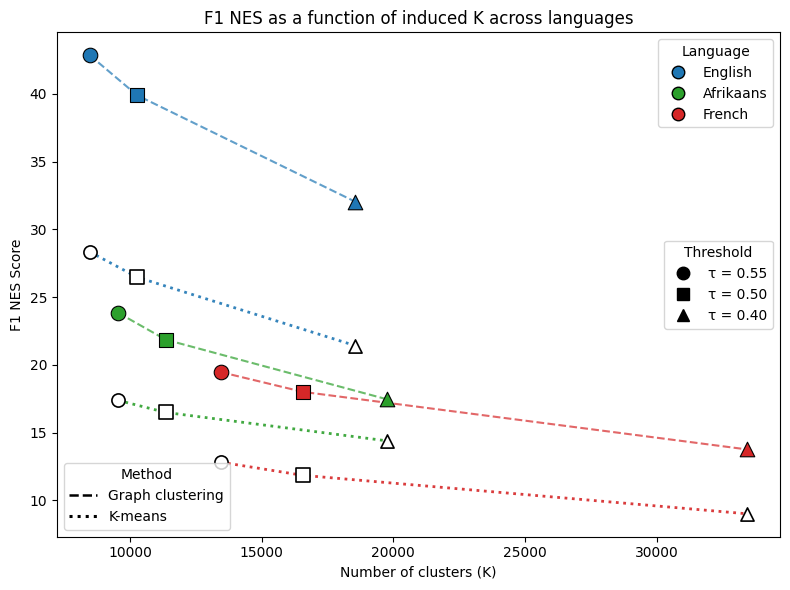

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Data
# -----------------------------
K = np.array([
    8467, 9548, 13438,
    10271, 11355, 16559,
    18555, 19777, 33443
])

F1 = np.array([
    42.85, 23.84, 19.47,
    39.89, 21.86, 18.01,
    32.04, 17.45, 13.76
])

language = np.array([
    "English", "Afrikaans", "French",
    "English", "Afrikaans", "French",
    "English", "Afrikaans", "French"
])

threshold = np.array([
    0.55, 0.55, 0.55,
    0.50, 0.50, 0.50,
    0.40, 0.40, 0.40
])

# -----------------------------
# K-means results
# same order as K / F1 / language / threshold above
# replace these example values with your actual K-means F1 values
# -----------------------------
F1_kmeans = np.array([
    28.34, 17.38, 12.82,   # threshold 0.55: English, Afrikaans, French
    26.47, 16.49, 11.85,   # threshold 0.50
    21.42, 14.39, 9.01    # threshold 0.40
])


# -----------------------------
# Style mappings
# -----------------------------
color_map = {
    "English": "tab:blue",
    "Afrikaans": "tab:green",
    "French": "tab:red"
}

marker_map = {
    0.55: "o",   # circle
    0.50: "s",   # square
    0.40: "^"    # triangle
}

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

# Add dashed lines connecting points within each language
for lang in np.unique(language):
    idx = np.where(language == lang)[0]

    # Sort points by threshold descending if you want 0.55 -> 0.50 -> 0.40
    order = np.argsort(-threshold[idx])
    idx = idx[order]

    plt.plot(
        K[idx],
        F1[idx],
        linestyle="--",
        linewidth=1.5,
        color=color_map[lang],
        alpha=0.7
    )

# Add scatter points with marker shape by threshold
for k, f1, lang, thr in zip(K, F1, language, threshold):
    plt.scatter(
        k,
        f1,
        s=110,
        color=color_map[lang],
        marker=marker_map[thr],
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

# K-means lines for each language
for lang in np.unique(language):
    idx = np.where(language == lang)[0]

    # Sort in threshold order, same as for graph lines
    order = np.argsort(-threshold[idx])
    idx = idx[order]

    plt.plot(
        K[idx],
        F1_kmeans[idx],
        linestyle=":",
        linewidth=2.0,
        color=color_map[lang],
        alpha=0.9
    )

# Add markers to K-means line at the graph-clustering K values
for k, f1_km, thr in zip(K, F1_kmeans, threshold):
    plt.scatter(
        k,
        f1_km,
        s=90,
        facecolors='white',
        edgecolors='black',
        marker=marker_map[thr],
        linewidth=1.2,
        zorder=4
    )

# -----------------------------
# Legends
# -----------------------------
# Language legend
language_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor=color_map[lang],
           markeredgecolor='black',
           markersize=9,
           label=lang)
    for lang in ["English", "Afrikaans", "French"]
]

# Threshold legend
threshold_handles = [
    Line2D([0], [0],
           marker=marker_map[thr],
           color='black',
           linestyle='None',
           markersize=9,
           label=f"τ = {thr:.2f}")
    for thr in [0.55, 0.50, 0.40]
]
method_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.8, label='Graph clustering'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=2.2, label='K-means')
]
legend1 = plt.legend(handles=language_handles, title="Language", loc="upper right")
legend2 = plt.legend(handles=threshold_handles, title="Threshold", loc="center right")

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)
plt.legend(handles=method_handles, title="Method", loc="lower left")

# -----------------------------
# Labels
# -----------------------------
plt.xlabel("Number of clusters (K)")
plt.ylabel("F1 NES Score")
plt.title("F1 NES as a function of K for different languages and thresholds")

plt.tight_layout()
plt.show()

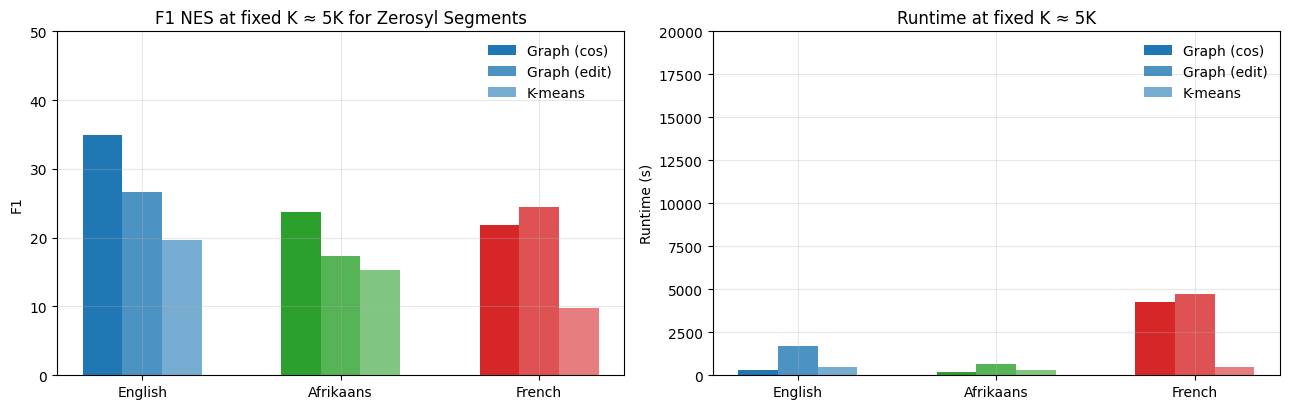

In [17]:
import matplotlib.pyplot as plt
import numpy as np

languages = ["English", "Afrikaans", "French"]


F1_kmeans = [19.68, 15.28, 9.82]
F1_cos =[34.94, 23.71, 21.85]
F1_edit = [26.60, 17.39, 24.42]

runtime_kmeans = [466.26, 315.73, 454.70]
runtime_cos = [314.84, 168.41, 4248.18]
runtime_edit = [1691.55, 643.10, 4724.29]

x = np.arange(len(languages))
bar_width = 0.2

colors = ["tab:blue", "tab:green", "tab:red"]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

# Panel 1: F1
axs[0].bar(x - bar_width, F1_cos, width=bar_width, color=colors, label="Graph (cos)")
axs[0].bar(x, F1_edit, width=bar_width, color=colors, alpha=0.8, label="Graph (edit)")
axs[0].bar(x + bar_width, F1_kmeans, width=bar_width, color=colors, alpha=0.6, label="K-means")
axs[0].set_xticks(x)
axs[0].set_xticklabels(languages)
axs[0].set_title("F1 NES at fixed K ≈ 5K for Zerosyl Segments")
axs[0].set_ylabel("F1")
axs[0].grid(True, alpha=0.3)
axs[0].set_ylim(0, 50)
axs[0].legend(frameon=False)

# Panel 2: Runtime
axs[1].bar(x - bar_width, runtime_cos, width=bar_width, color=colors, label="Graph (cos)")
axs[1].bar(x, runtime_edit, width=bar_width, color=colors, alpha=0.8, label="Graph (edit)")
axs[1].bar(x + bar_width, runtime_kmeans, width=bar_width, color=colors, alpha=0.6, label="K-means")
axs[1].set_xticks(x)
axs[1].set_xticklabels(languages)
axs[1].set_title("Runtime at fixed K ≈ 5K")
axs[1].set_ylabel("Runtime (s)")
axs[1].grid(True, alpha=0.3)
axs[1].set_ylim(0, 20000)
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


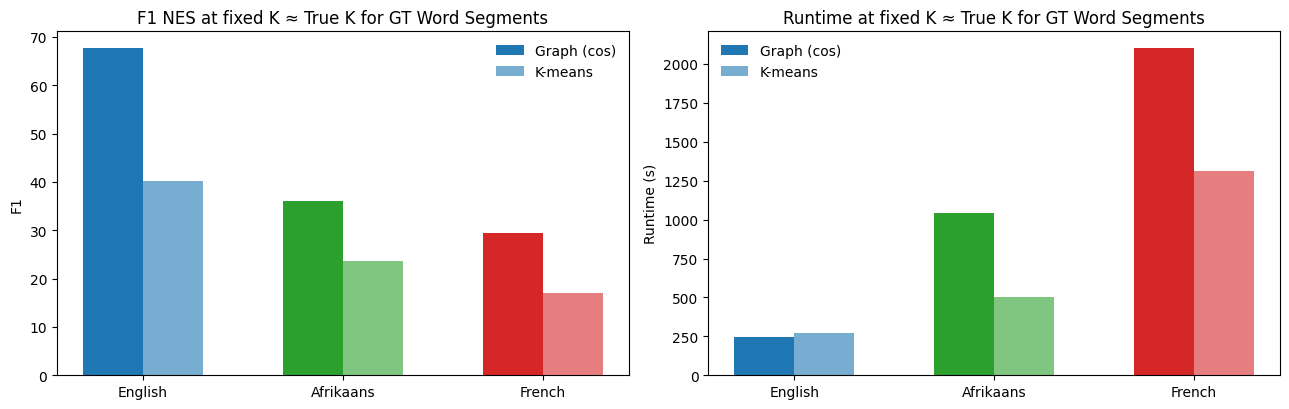

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

languages = ["English", "Afrikaans", "French"]

F1_kmeans = [40.26, 23.69, 16.96]
F1_cos =[67.76, 36.08, 29.45]

runtime_kmeans = [269.82, 503.91, 1309.21]
runtime_cos = [248.49, 1041.55, 2103.87]

x = np.arange(len(languages))
bar_width = 0.3

colors = ["tab:blue", "tab:green", "tab:red"]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

# Panel 1: F1
axs[0].bar(x - bar_width/2, F1_cos, width=bar_width, color=colors, label="Graph (cos)")
axs[0].bar(x + bar_width/2, F1_kmeans, width=bar_width, color=colors, alpha=0.6, label="K-means")
axs[0].set_xticks(x)
axs[0].set_xticklabels(languages)
axs[0].set_title("F1 NES at fixed K ≈ 5K for ZeroSyl Segments")
axs[0].set_ylabel("F1")
axs[0].legend(frameon=False)

# Panel 2: Runtime
axs[1].bar(x - bar_width/2, runtime_cos, width=bar_width, color=colors, label="Graph (cos)")
axs[1].bar(x + bar_width/2, runtime_kmeans, width=bar_width, color=colors, alpha=0.6, label="K-means")
axs[1].set_xticks(x)
axs[1].set_xticklabels(languages)
axs[1].set_title("Runtime at fixed K ≈ 5K for ZeroSyl Segments")
axs[1].set_ylabel("Runtime (s)")
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


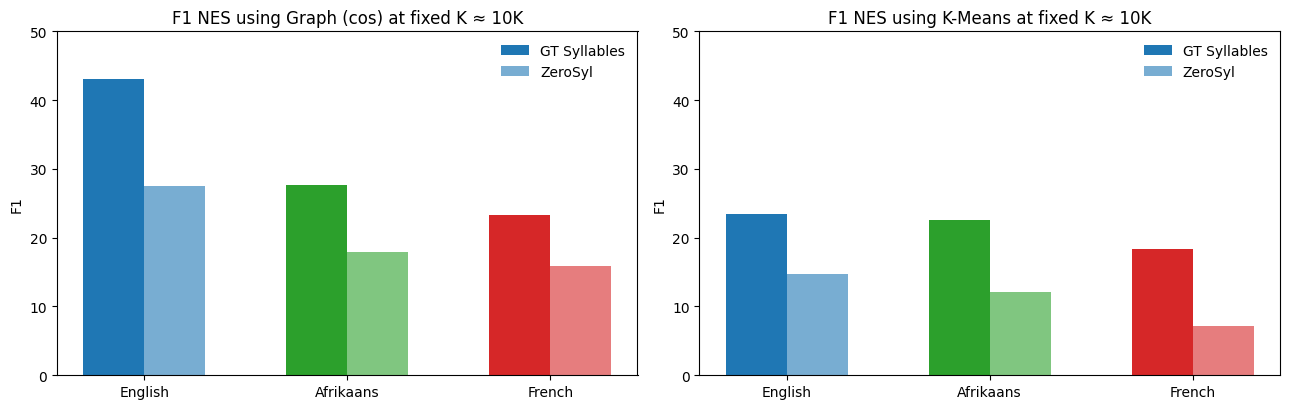

In [12]:
import matplotlib.pyplot as plt
import numpy as np

languages = ["English", "Afrikaans", "French"]

F1_GT = [43.09, 27.59, 23.31]
F1_ZeroSyl =[27.54, 17.91, 15.86]

F1_GT_kmeans = [23.51, 22.62, 18.31]
F1_ZeroSyl_kmeans = [14.78, 12.09, 7.13]

x = np.arange(len(languages))
bar_width = 0.3

colors = ["tab:blue", "tab:green", "tab:red"]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

# Panel 1: F1
axs[0].bar(x - bar_width/2, F1_GT, width=bar_width, color=colors, label="GT Syllables")
axs[0].bar(x + bar_width/2, F1_ZeroSyl, width=bar_width, color=colors, alpha=0.6, label="ZeroSyl")
axs[0].set_xticks(x)
axs[0].set_xticklabels(languages)
axs[0].set_title("F1 NES using Graph (cos) at fixed K ≈ 10K")
axs[0].set_ylabel("F1")
axs[0].set_ybound(0, 50)
axs[0].legend(frameon=False)

# Panel 2: Runtime
axs[1].bar(x - bar_width/2, F1_GT_kmeans, width=bar_width, color=colors, label="GT Syllables")
axs[1].bar(x + bar_width/2, F1_ZeroSyl_kmeans, width=bar_width, color=colors, alpha=0.6, label="ZeroSyl")
axs[1].set_xticks(x)
axs[1].set_xticklabels(languages)
axs[1].set_title("F1 NES using K-Means at fixed K ≈ 10K")
axs[1].set_ylabel("F1")
axs[1].set_ybound(0, 50)
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


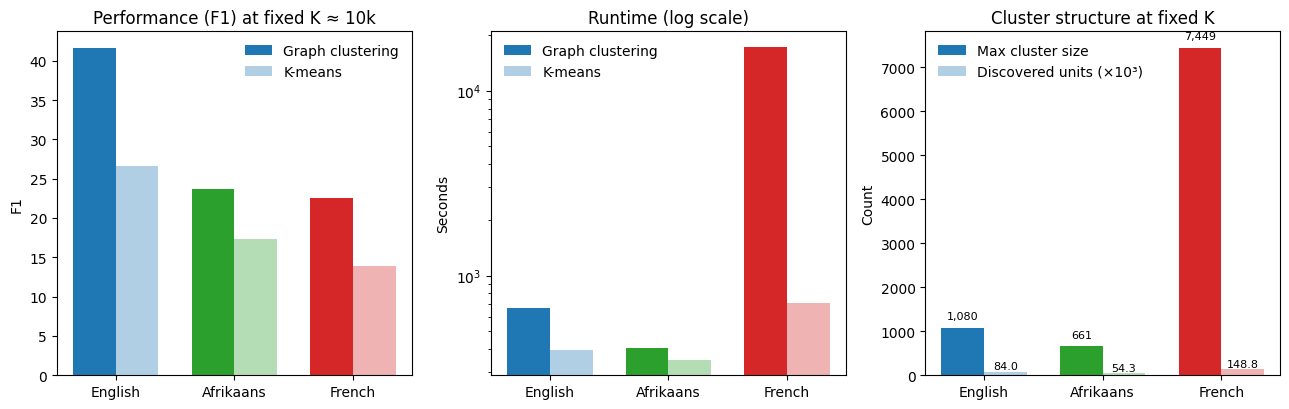

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

languages = ["English", "Afrikaans", "French"]

F1 = [41.65, 23.70, 22.53]
F1_kmeans = [26.66, 17.31, 13.90]
runtime = [667.44, 406.79, 17232.74]
runtime_kmeans = [394.03, 350.90, 713.92]
max_cluster = [1080, 661, 7449]
units = [83961, 54315, 148815]


units_k = [u / 1000 for u in units]

x = np.arange(len(languages))
bar_width = 0.36

colors = ["tab:blue", "tab:green", "tab:red"]

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2))

# Panel 1: F1
axs[0].bar(x - bar_width/2, F1, width=bar_width, color=colors, label="Graph (cos)")
axs[0].bar(x + bar_width/2, F1_kmeans, width=bar_width, color=colors, alpha=0.35, label="K-means")
axs[0].set_xticks(x)
axs[0].set_xticklabels(languages)
axs[0].set_title("Performance (F1) at fixed K ≈ 10k")
axs[0].set_ylabel("F1")
axs[0].legend(frameon=False)

# Panel 2: Runtime
axs[1].bar(x - bar_width/2, runtime, width=bar_width, color=colors, label="Graph (cos)")
axs[1].bar(x + bar_width/2, runtime_kmeans, width=bar_width, color=colors, alpha=0.35, label="K-means")
axs[1].set_xticks(x)
axs[1].set_xticklabels(languages)
axs[1].set_yscale("log")
axs[1].set_title("Runtime (log scale)")
axs[1].set_ylabel("Seconds")
axs[1].legend(frameon=False)

# Panel 3: Cluster structure
axs[2].bar(x - bar_width/2, max_cluster, width=bar_width, color=colors, label="Max cluster size")
axs[2].bar(x + bar_width/2, units_k, width=bar_width, color=colors, alpha=0.35, label="Discovered units (×10³)")

axs[2].set_xticks(x)
axs[2].set_xticklabels(languages)
axs[2].set_title("Cluster structure at fixed K")
axs[2].set_ylabel("Count")
axs[2].legend(frameon=False)

# Optional value labels
for i, v in enumerate(max_cluster):
    axs[2].text(i - bar_width/2, v + max(max_cluster)*0.02, f"{v:,}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(units_k):
    axs[2].text(i + bar_width/2, v + max(units_k)*0.02, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [80]:
from pathlib import Path
from pooling import load_pooled_features
import numpy as np

feature_dir = Path("pooled_features/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/norm-prom-seg/prominence_0.35_window_3")
features, filenames, intervals = load_pooled_features(feature_dir)

feature_keys = []
for fname, (start, end) in zip(filenames, intervals):
    start_str = str(np.round(float(start), 4)).rstrip("0").rstrip(".")
    end_str = str(np.round(float(end), 4)).rstrip("0").rstrip(".")
    feature_keys.append(f"{fname} {start_str} {end_str}")

Loading pooled features: 100%|██████████| 83974/83974 [00:07<00:00, 11541.25it/s]


Loaded 83972 pooled feature files. Ex: (350,) from 1272-128104-0000-0000 with interval (0, 8)


In [98]:
def seconds_to_frames(seconds, ms_per_frame=20):
    return np.floor(np.round((seconds / ms_per_frame * 1000), 1) + 0.5).astype(np.int32)

partition_path = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/norm-prom-seg/prominence_0.35_window_3/knn_cosine_k500_t0.7_r1.0265_1083.95.txt")
dataset = partition_path.parts[1:3]
print(f"Processing partition for dataset: {' '.join(dataset)}") 
partition_type = partition_path.stem.split("_")[0]  # e.g., "cosine"
title = f"Partitioning of features for {partition_type} clustering\n[{dataset[0]} {dataset[1]}]"
print(title)
part_keys = []
part_cluster_ids = []

current_class = None

with open(partition_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith("Class"):
            current_class = int(line.split()[1])
            continue

        parts = line.split()
        if len(parts) != 3:
            raise ValueError(f"Unexpected line format: {line}")

        utt, start, end = parts
        start = seconds_to_frames(float(start))
        end = seconds_to_frames(float(end))
        key = f"{utt} {start} {end}"
        part_keys.append(key)
        part_cluster_ids.append(current_class)

key_to_cluster = dict(zip(part_keys, part_cluster_ids))

missing = [k for k in feature_keys if k not in key_to_cluster]
if missing:
    raise ValueError(
        f"{len(missing)} feature keys were not found in partition file. "
        f"First few missing:\n{missing[:10]}"
    )

cluster_ids_aligned = np.array([key_to_cluster[k] for k in feature_keys], dtype=int)

unique_clusters = np.unique(cluster_ids_aligned)
centroids = []
centroid_cluster_ids = []

for cid in unique_clusters:
    members = features[cluster_ids_aligned == cid]
    centroid = members.mean(axis=0)
    centroids.append(centroid)
    centroid_cluster_ids.append(cid)

centroids = np.vstack(centroids)
centroid_cluster_ids = np.array(centroid_cluster_ids)

Processing partition for dataset: LibriSpeech dev-clean_feature_sliced
Partitioning of features for knn clustering
[LibriSpeech dev-clean_feature_sliced]


In [28]:
from sklearn.manifold import TSNE

perplexity = 300
centroids = centroids - np.mean(centroids, axis=0)
centroids = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
X = np.vstack([features, centroids])
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=perplexity,
    max_iter=1000,
    random_state=42
)
tsne_embedding = tsne.fit_transform(X)
feature_emb_tsne = tsne_embedding[:len(features)]
centroid_emb_tsne = tsne_embedding[len(features):]

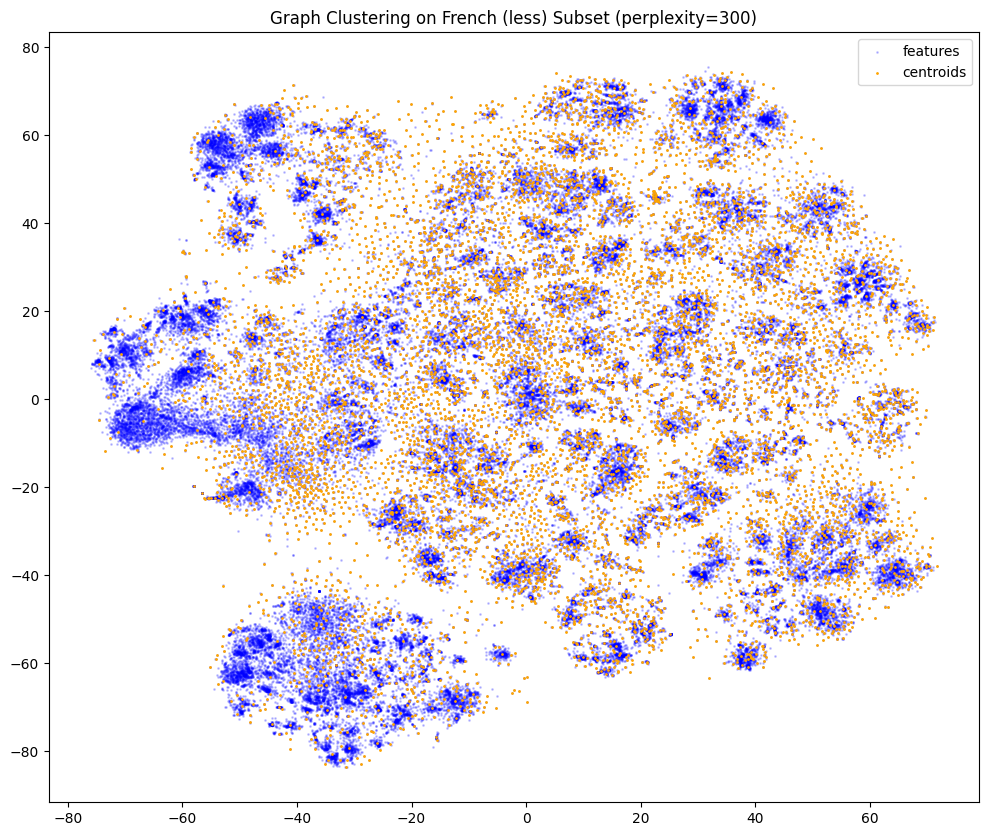

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.scatter(feature_emb_tsne[:, 0], feature_emb_tsne[:, 1], c='blue', s=1, alpha=0.2, label='features')
plt.scatter(centroid_emb_tsne[:, 0], centroid_emb_tsne[:, 1], c='orange', s=1, label='centroids')

plt.title(f'Graph Clustering on French (less) Subset (perplexity={perplexity})')
plt.legend()
plt.show()

In [ ]:
import umap
import matplotlib.pyplot as plt

centroids = centroids - centroids.mean(axis=0, keepdims=True)
centroids = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
X = np.vstack([features, centroids])
embedding = umap.UMAP(
    n_components=2,
    metric="cosine"
).fit_transform(X)

feature_emb = embedding[:len(features)]
centroid_emb = embedding[len(features):]


plt.figure(figsize=(12, 10))
plt.scatter(feature_emb[:, 0], feature_emb[:, 1], c='blue', s=1, alpha=0.2, label='features')
plt.scatter(centroid_emb[:, 0], centroid_emb[:, 1], c='orange', s=1, label='centroids')

plt.title(f'Graph Clustering on French Subset ZeroSyl (K=10,000)')
plt.legend()
plt.show()


/home/danel/.pyenv/versions/3.12.11/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using 83972 features from 9977 biggest clusters for TSNE


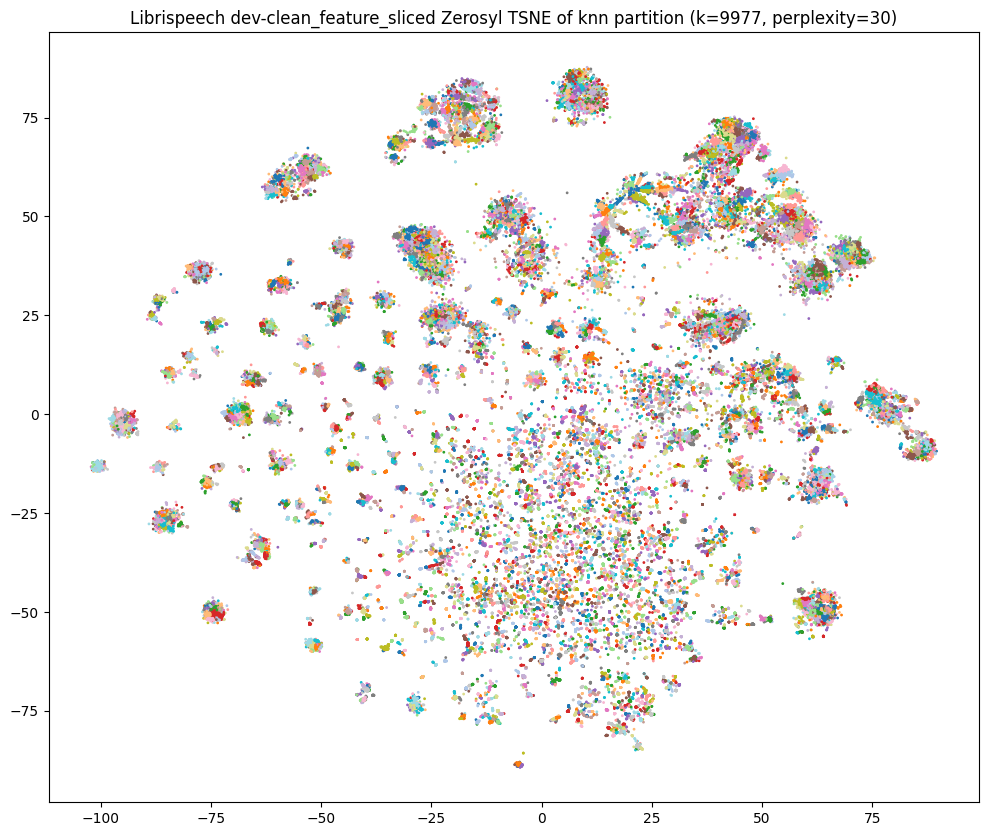

In [101]:
from sklearn.manifold import TSNE

biggest_clusters = np.argsort([np.sum(cluster_ids_aligned == cid) for cid in unique_clusters])
features_subset = features[np.isin(cluster_ids_aligned, biggest_clusters)]
print(f"Using {features_subset.shape[0]} features from {len(biggest_clusters)} biggest clusters for TSNE")

tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=300,
    max_iter=1000,
    random_state=42
)
tsne_embedding = tsne.fit_transform(features_subset)

cluster_ids_subset = cluster_ids_aligned[np.isin(cluster_ids_aligned, biggest_clusters)]
colors_by_id = {cid: plt.cm.tab20(i % 20) for i, cid in enumerate(unique_clusters)}

plt.figure(figsize=(12, 10))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=[colors_by_id[cid] for cid in cluster_ids_subset], s=1, alpha=1.0)
plt.title(f"{' '.join(dataset).capitalize()} Zerosyl TSNE of {partition_type} partition (k={len(set(cluster_ids_subset))}, perplexity=30)")
plt.show()

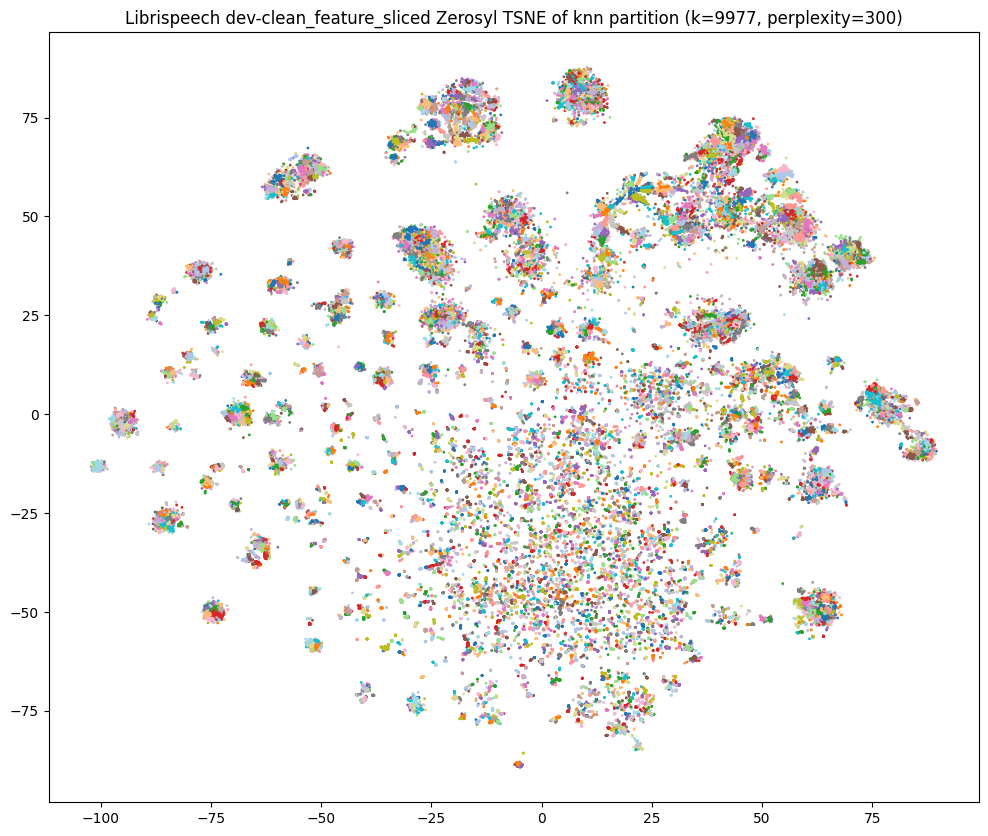

In [102]:
plt.figure(figsize=(12, 10))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=[colors_by_id[cid] for cid in cluster_ids_subset], s=1, alpha=1.0)
plt.title(f"{' '.join(dataset).capitalize()} Zerosyl TSNE of {partition_type} partition (k={len(set(cluster_ids_subset))}, perplexity=300)")
plt.show()

In [83]:
import umap

biggest_clusters = np.argsort([np.sum(cluster_ids_aligned == cid) for cid in unique_clusters])[-100:]
features_subset = features[np.isin(cluster_ids_aligned, biggest_clusters)]
print(f"Using {features_subset.shape[0]} features from {len(biggest_clusters)} biggest clusters for UMAP")

mapper = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
).fit(features_subset)


Using 20449 features from 100 biggest clusters for UMAP


/home/danel/.pyenv/versions/3.12.11/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


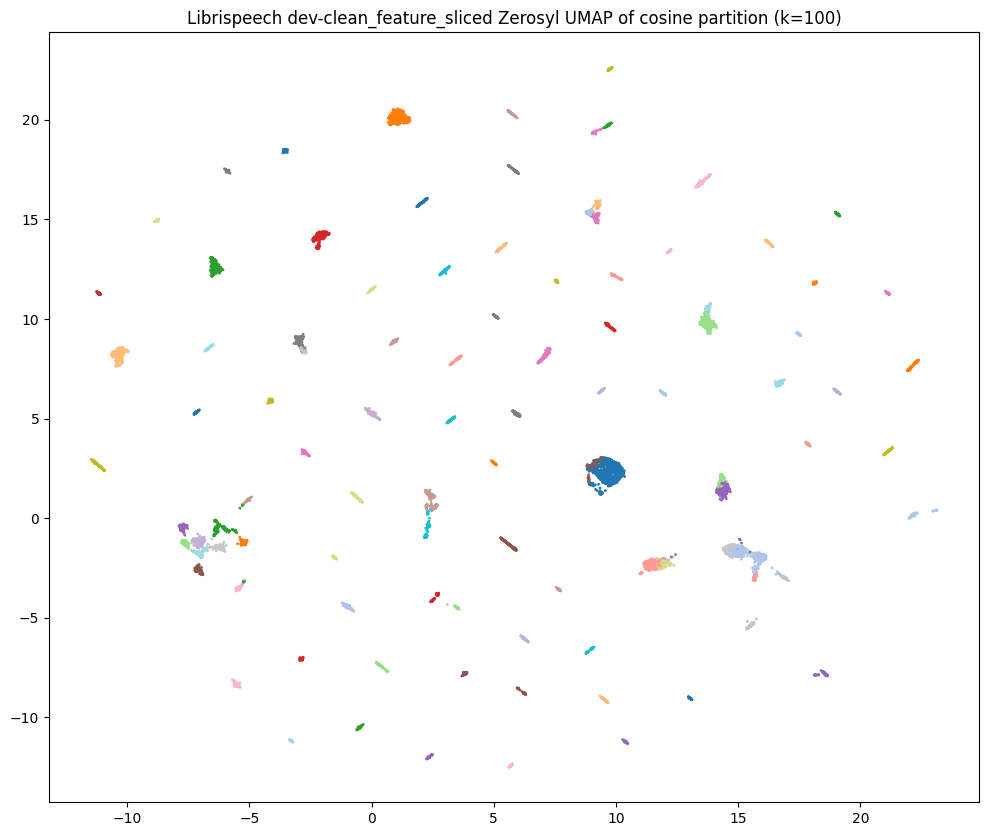

In [84]:
import matplotlib.pyplot as plt

cluster_ids_subset = cluster_ids_aligned[np.isin(cluster_ids_aligned, biggest_clusters)]
colors_by_id = {cid: plt.cm.tab20(i % 20) for i, cid in enumerate(unique_clusters)}

plt.figure(figsize=(12, 10))
plt.scatter(mapper.embedding_[:, 0], mapper.embedding_[:, 1], c=[colors_by_id[cid] for cid in cluster_ids_subset], s=1, alpha=1.0)
plt.title(f"{' '.join(dataset).capitalize()} Zerosyl UMAP of {partition_type} partition (k={len(set(cluster_ids_subset))})")
plt.show()
